In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp


# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

In [3]:
# 결과받을 딕셔너리
results = {}

In [4]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [5]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [6]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [7]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [8]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [9]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [10]:
# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_over, y_over, size=0.4)

In [11]:
# 6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# 모델별 스페이스 생성
mlp_search_space = {`
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', [
        (64,),
        (128,),
        (128, 64),
        (256, 128, 64)
    ]),
    
    'activation': hp.choice('activation', ['relu', 'tanh']),    

    'solver': hp.choice('solver', ['adam']),  # adam이 대부분 더 안정적

    # dropout 효과 대신 alpha를 넓게 줌
    'alpha': hp.loguniform('alpha', -6, -1),  # 1e-6 ~ 1e-1

    # learning rate는 adam 기준 safe zone
    'learning_rate_init': hp.uniform('learning_rate_init', 0.0005, 0.01),

    # SGD 쓸 경우 필요하지만 adam이면 과하게 튜닝할 필요 없음
    'batch_size': hp.choice('batch_size', [32, 64, 128]),

    # 너무 큰 max_iter은 오버, early stopping 쓰면 적당
    'max_iter': hp.quniform('max_iter', 150, 400, 50),

    # learning schedule (고성능에서 중요)
    'learning_rate': hp.choice('learning_rate', ['constant', 'adaptive'])
}


mlp = MLPClassifier()

# 파라미터 지정
best_params, best_mlp, trials, exec_time = tuner.tune(
    mlp, X_tr, y_tr, X_val, y_val, mlp_search_space
)

# best모델 결과 출력
model_name = 'mlp_ho_best'
results[model_name] = uu.get_model_train_eval(
    best_mlp, model_name, X_train, X_test, y_train, y_test, best_params
)


MLPClassifier 튜닝 시작
100%|██████████| 100/100 [2:16:49<00:00, 82.09s/trial, best loss: -1.0]               

튜닝 시간: 8209.48초
최적 recall: 1.0000

최적 모델의 전체 평가 점수:
- roc_auc: 0.9998
- f1: 0.9951
- precision: 0.9902
- recall: 1.0000
- accuracy: 0.9950

최적 하이퍼파라미터:
-activation: tanh
-alpha: 0.002516599485282235
-batch_size: 64
-hidden_layer_sizes: (64,)
-learning_rate: constant
-learning_rate_init: 0.0030330162780577313
-max_iter: 150
-solver: adam
-random_state: 23
✓ 모델 저장 완료: ../models\mlp_ho_best.pkl
  파일 크기: 0.07 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9595, '정확도': 0.9994, '정밀도': 0.8351, '재현율': 0.8265, 'F1': 0.8308 }
{'오차행렬':
[[56848    16]
 [   17    81]] }
실행 시간: 18.84601140022278
하이퍼파라미터: {'activation': 'tanh', 'alpha': 0.002516599485282235, 'batch_size': 64, 'hidden_layer_sizes': (64,), 'learning_rate': 'constant', 'learning_rate_init': 0.0030330162780577313, 'max_iter': 150, 'solver': 'adam', 'random_state': 23}


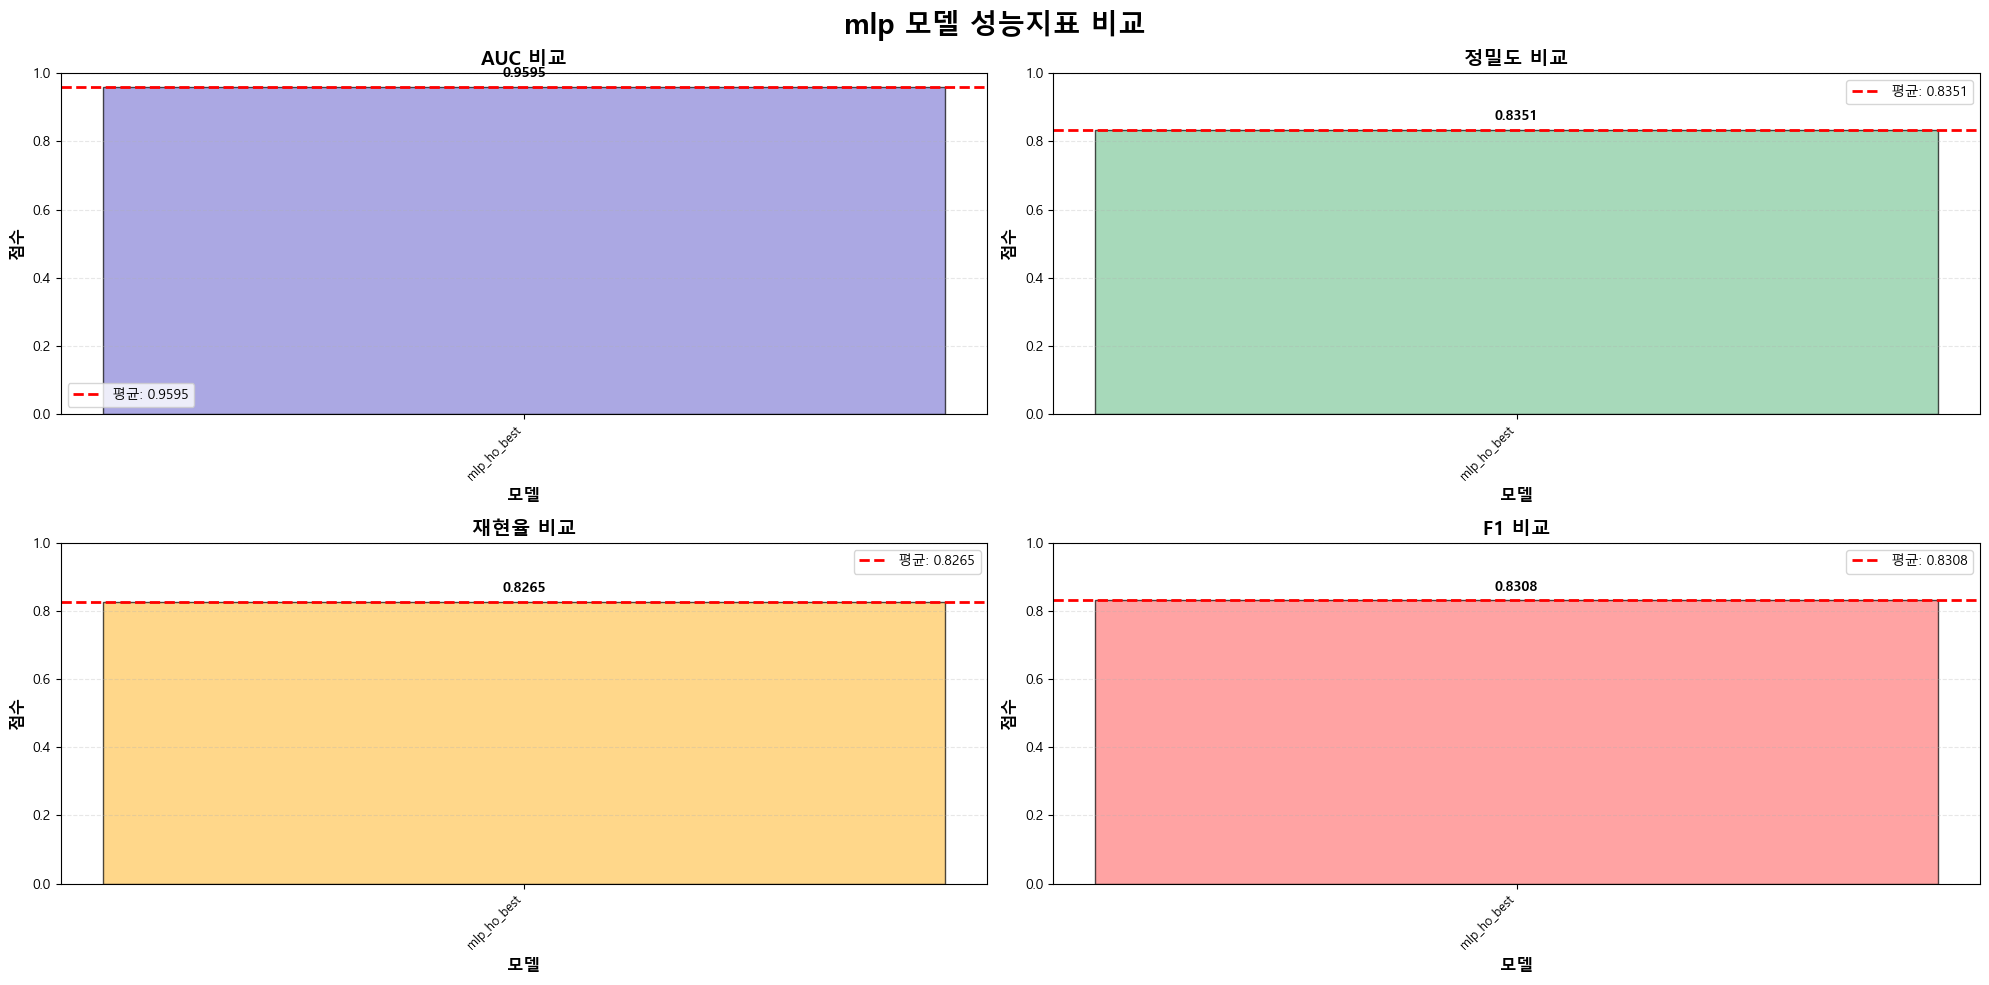


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9595 (mlp_ho_best)
  최저: 0.9595 (mlp_ho_best)
  평균: 0.9595
  표준편차: nan

[정밀도]
  최고: 0.8351 (mlp_ho_best)
  최저: 0.8351 (mlp_ho_best)
  평균: 0.8351
  표준편차: nan

[재현율]
  최고: 0.8265 (mlp_ho_best)
  최저: 0.8265 (mlp_ho_best)
  평균: 0.8265
  표준편차: nan

[F1]
  최고: 0.8308 (mlp_ho_best)
  최저: 0.8308 (mlp_ho_best)
  평균: 0.8308
  표준편차: nan


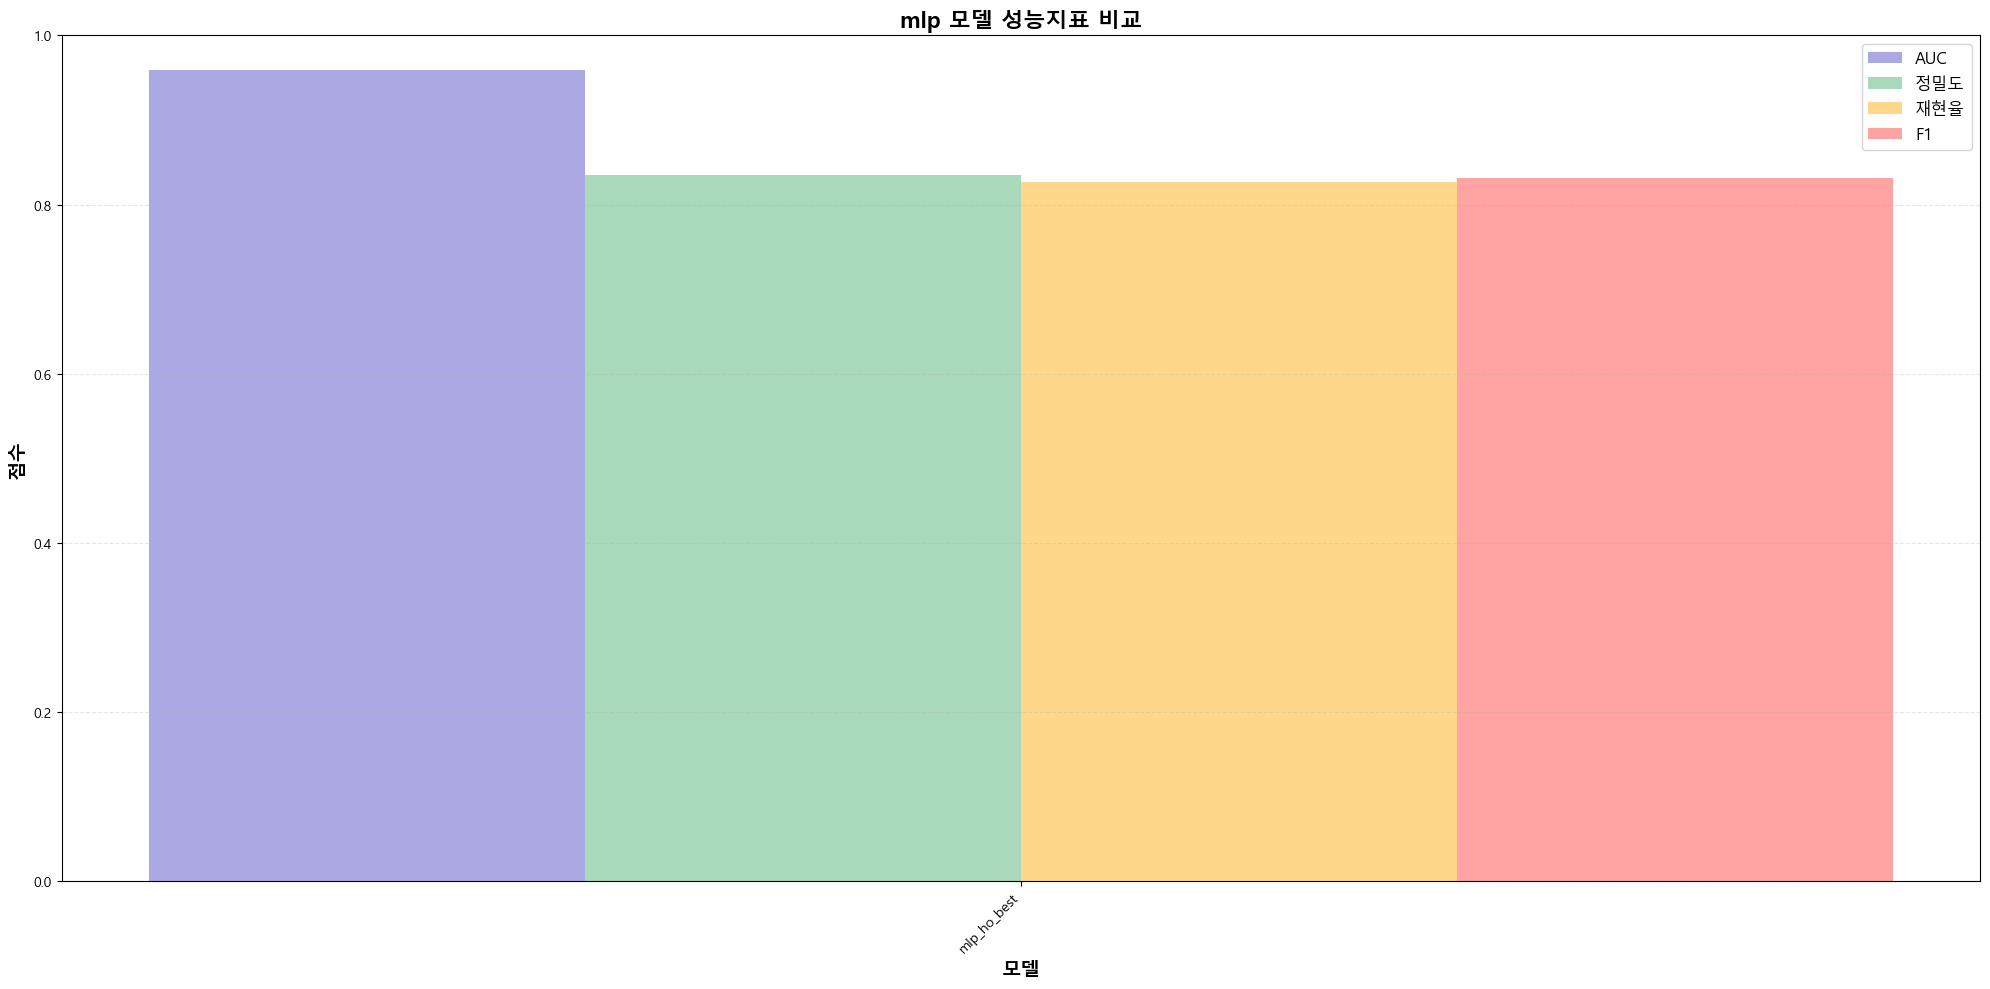


=== F1 Score 기준 상위 5개 모델 ===
                AUC     정밀도     재현율      F1
mlp_ho_best  0.9595  0.8351  0.8265  0.8308

그래프가 저장되었습니다: ../images/mlp_모델_성능지표_비교_2025_1128.png


In [12]:
# 7 시각화
mo.model_metrics_graph(results, 'mlp 모델 성능지표 비교')

In [13]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기 
# X_train_scaled, X_test_scaled, scaler = pp.scale_data(X_train, X_test)